In [1]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Ridge
from sklearn.model_selection import GridSearchCV                                 
import numpy as np 

In [2]:
rng = np.random.default_rng(6740)


In [3]:
data = loadmat('data/cs.mat')['img']

In [4]:
A = rng.normal(loc=0,scale=1,size=(1300,2500))
x = data.reshape(-1,1)
e = rng.normal(loc=0,scale=5,size=(1300,1))

In [5]:
y=(A.dot(x)+e).flatten()

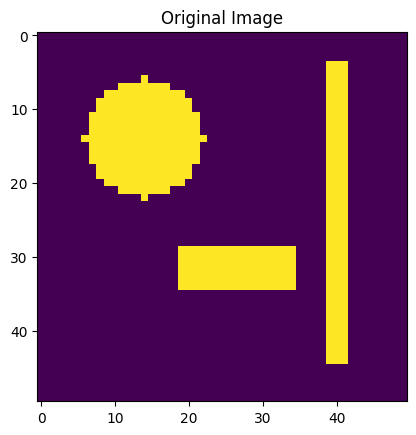

In [6]:
plt.title('Original Image')
plt.imshow(data)

In [7]:
lasso_model = LassoCV(cv=10, alphas=np.logspace(-2, .5, 100), random_state=6740)# lasso_model= LassoCV(cv=10,random_state=6740,alphas=5)

In [13]:
l=lasso_model.fit(A,y)

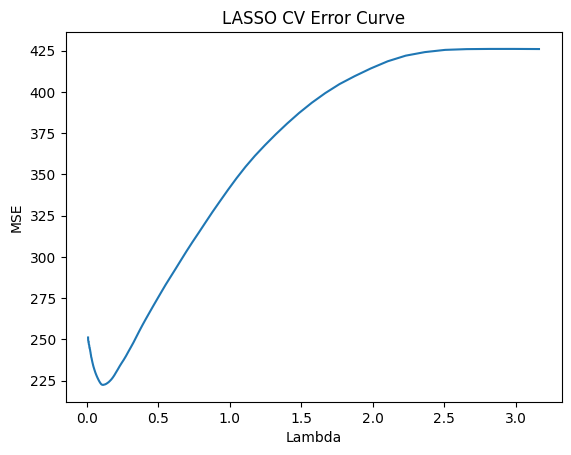

In [11]:
# plt.plot(np.log(lasso_model.alphas_),lasso_model.mse_path_.mean(axis=1))
plt.title("LASSO CV Error Curve")
plt.xlabel('Lambda')
plt.ylabel('MSE')

plt.plot((lasso_model.alphas_),lasso_model.mse_path_.mean(axis=1))

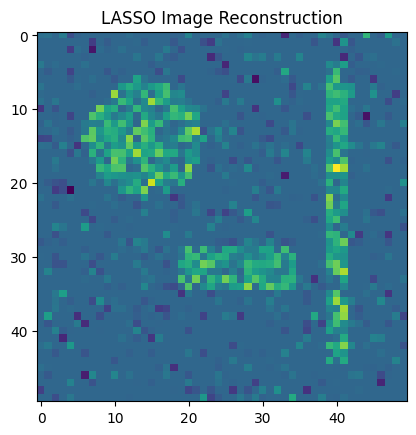

In [14]:
plt.title("LASSO Image Reconstruction")
plt.imshow(l.coef_.reshape(50,50))

In [15]:
ridge_model = GridSearchCV(Ridge(), param_grid={'alpha': np.logspace(-1, 3, 100)},                     
                      scoring='neg_mean_squared_error', cv=10) 

In [16]:
r=ridge_model.fit(A,y)

In [17]:
ridge_mse=-ridge_model.cv_results_['mean_test_score']
best_r = ridge_model.best_estimator_
ridge_image = best_r.coef_.reshape(50,50)


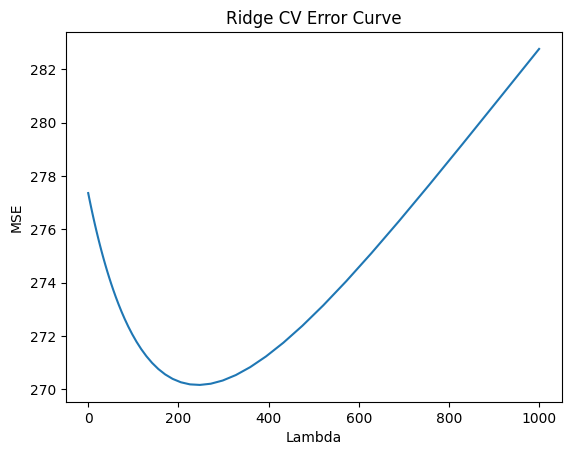

In [18]:
plt.title("Ridge CV Error Curve")
plt.xlabel('Lambda')
plt.ylabel('MSE')

plt.plot((np.logspace(-1, 3, 100)),ridge_mse)

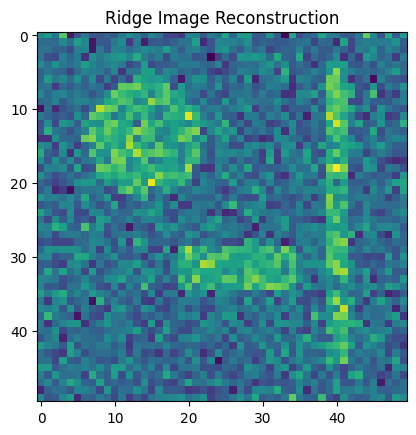

In [19]:
plt.title("Ridge Image Reconstruction")

plt.imshow(ridge_image)